#### Sunwoo Lee
#### 18th March 2026

# Assignment 3 - Predictive Modeling for Heart Failure Patients (Regression, Classification, Dimensionality Reduction, and Feature Selection)

## Task 1: Exploratory Data Analysis (EDA)

### Task Imports

In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# df = pd.read_csv('heart_failure_clinical_records_with_severity.csv')

### 1.1 Data Overview

#### Display first rows

In [92]:
df. head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,Severity
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1,6.6
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1,2.0
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1,6.4
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1,4.6
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1,8.8


#### Summary statistics

In [94]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,Severity
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000,299.000000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107,3.107692
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767,1.804331
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000,0.000000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000,1.800000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000,2.600000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000,4.300000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000,8.800000


#### Data types

In [96]:
df.dtypes

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
Severity                    float64
dtype: object

#### Missing values

In [98]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
Severity                    0
dtype: int64

#### Class distribution of DEATH_EVENT

In [100]:
df['DEATH_EVENT'].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

### 1.2 Visualization

#### Histograms

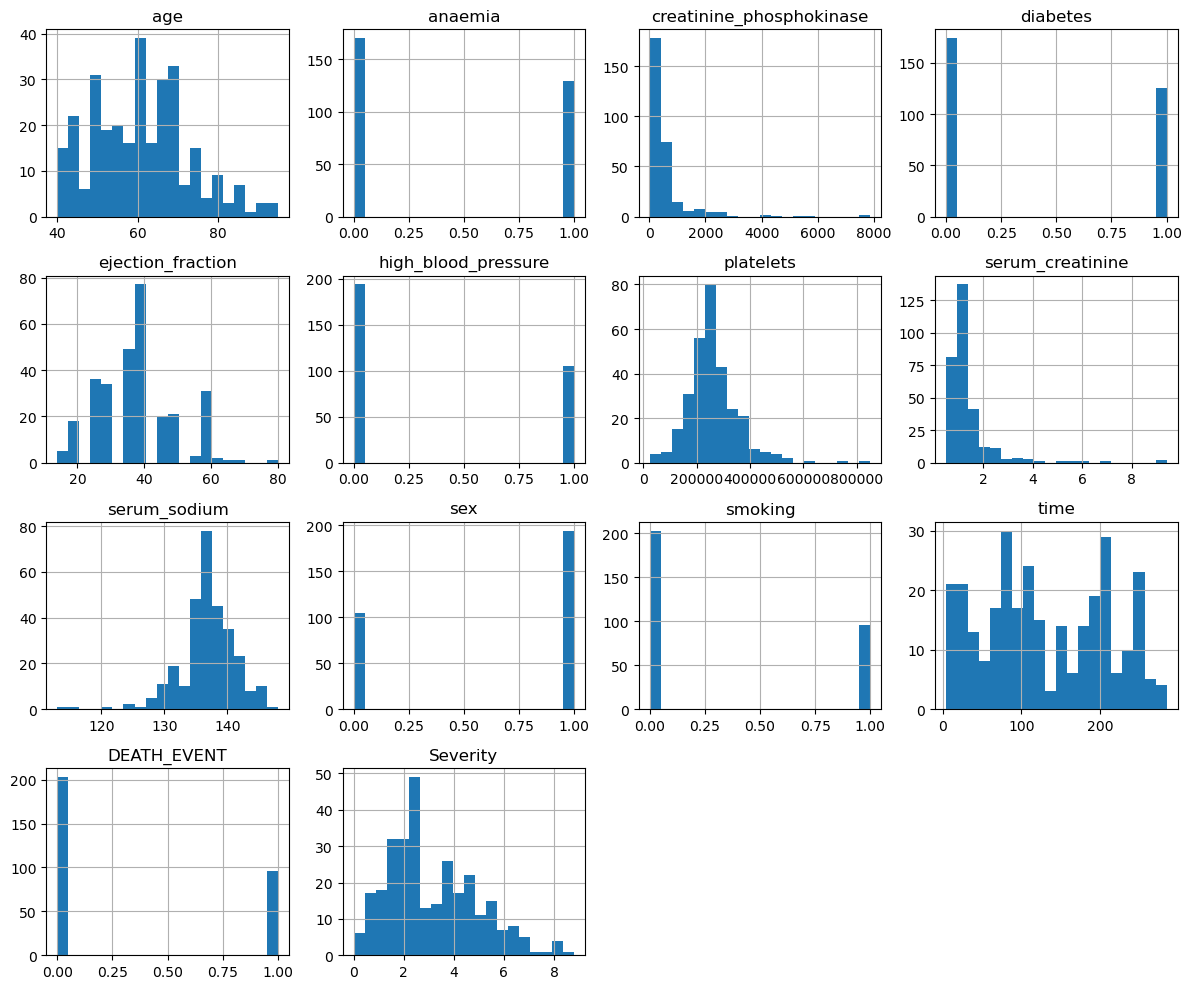

In [134]:
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

#### Boxplots

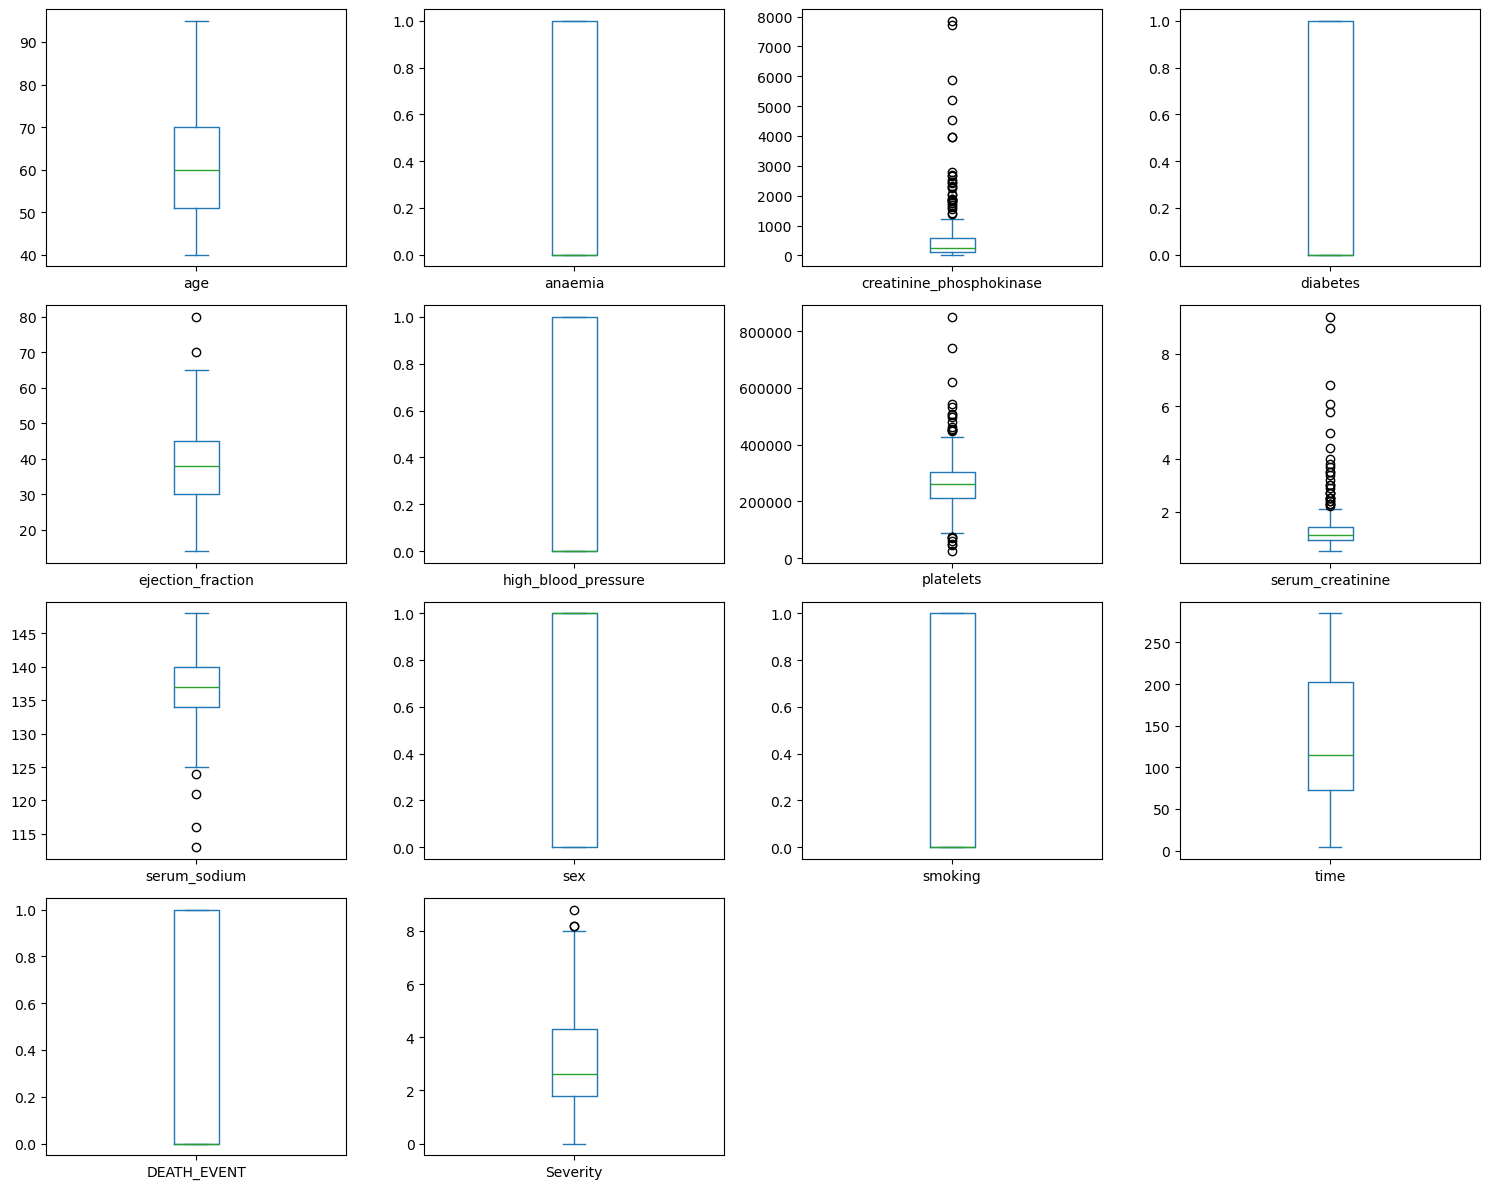

In [136]:
df.plot(kind='box', subplots=True, layout=(4, 4), figsize=(15, 12), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

#### Correlation heatmap

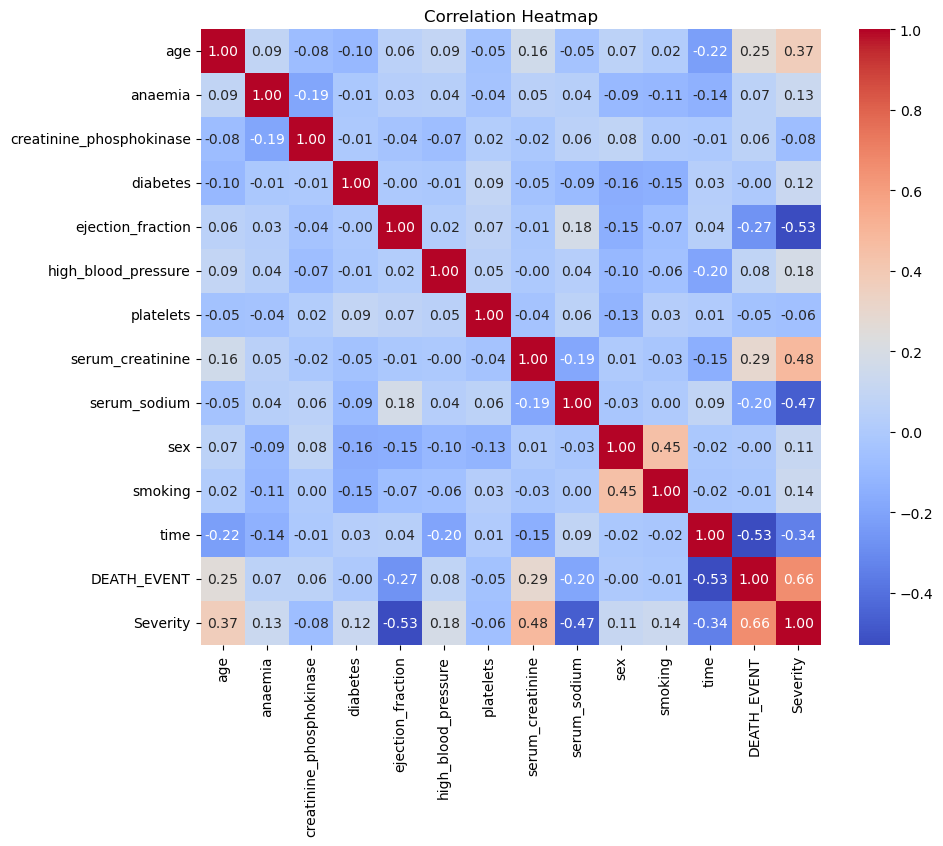

In [120]:
plt.figure(figsize=(10, 8))
corr = df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### Selected pairplots

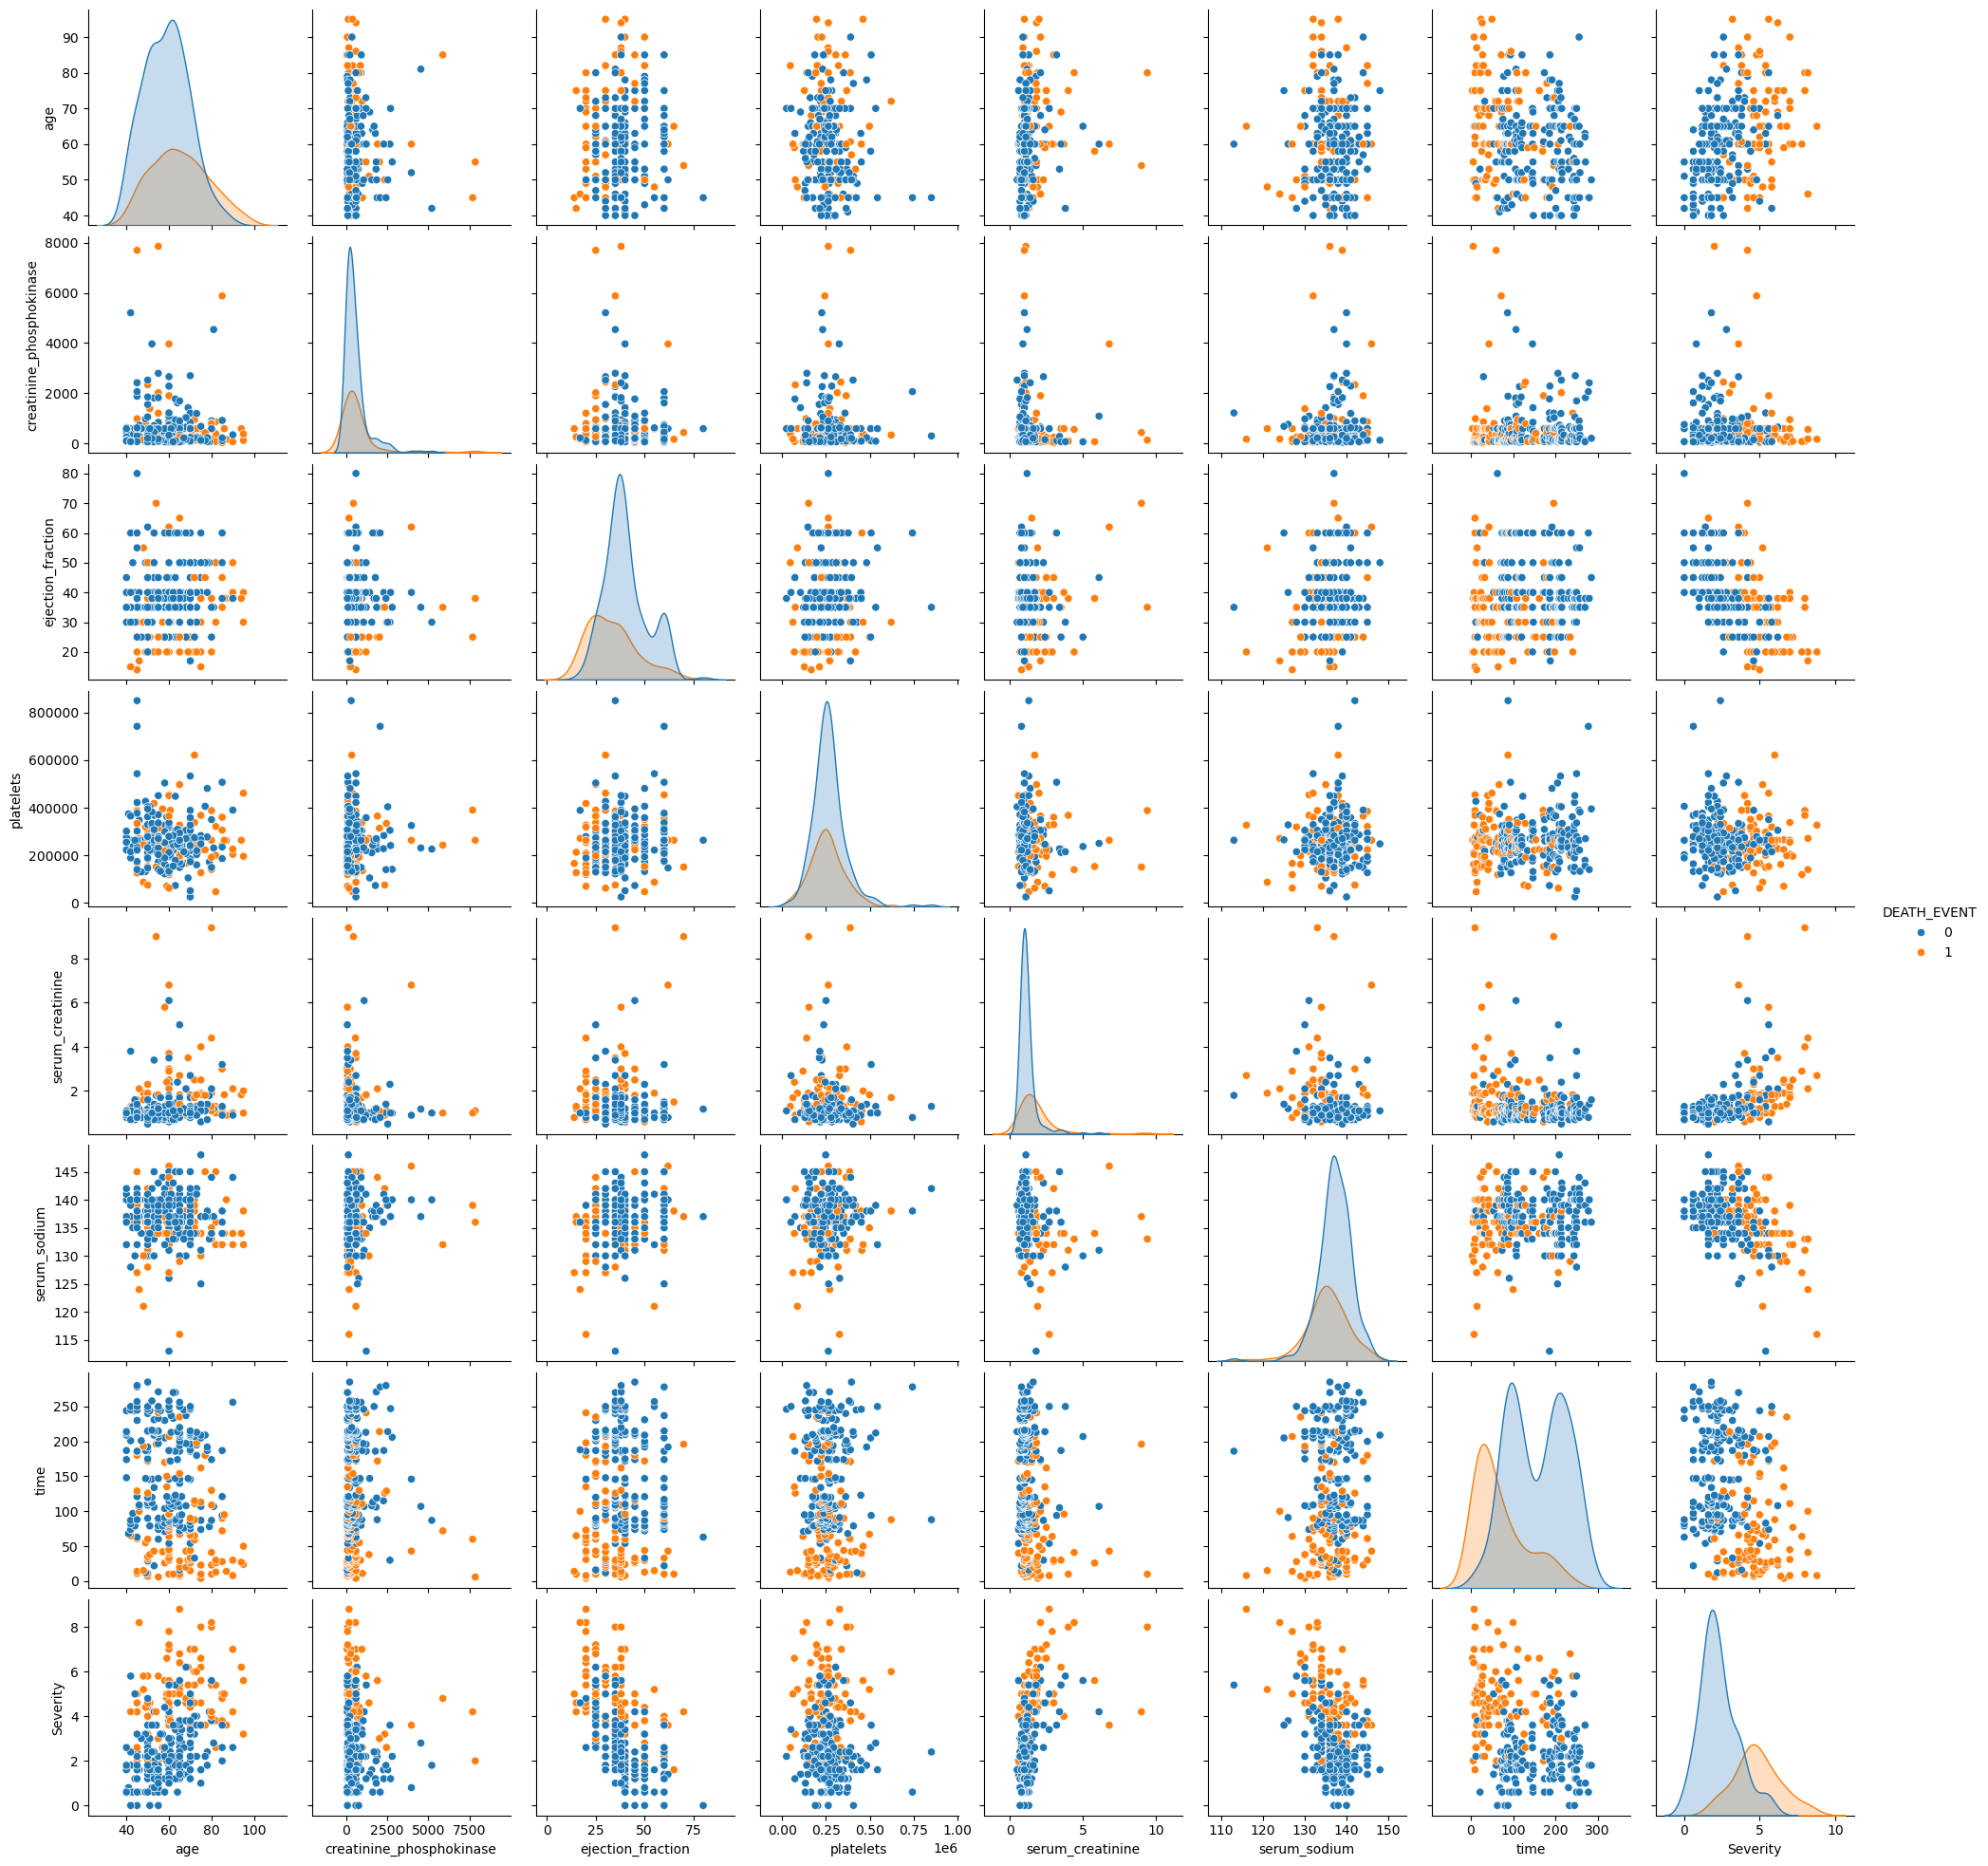

In [138]:
selected_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets',
                 'serum_creatinine', 'serum_sodium', 'time', 'Severity', 'DEATH_EVENT']

sns.pairplot(df[selected_cols], hue='DEATH_EVENT')
plt.show()

### 1.3 Written Observations (Required)
Explain:
- Which features appear strongly correlated with DEATH_EVENT?
- Which features appear related to Severity?
- Are there any outliers?
- Is there a class imbalance problem?

1. Time has strong negative correlation with ejection_fraction and serum_sodium having moderate negative correlation with age and serum_creatinine having moderate positive correlation.
2. Age and serum_creatinine has strong positive correlation, while ejection_fraction and serum_sodium has strong negative correlation.
3. Creatinine_phosphokinase, platelets, and serum_creatinine all show outliers from the box plots.
4. With a class distribution of 203 not dead and 96 dead, there is about 2:1 class distribution.

## Task 2: Regression Analysis (Predicting Severity)
> ignoring DEATH_EVENT

### Task Imports

In [286]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.kernel_ridge import KernelRidge

In [217]:
# Excluding DEATH_EVENT
X = df.drop(columns=['DEATH_EVENT', 'Severity'])

# Target
y = df['Severity']

# All numerical columns
num_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
            'platelets', 'serum_creatinine', 'serum_sodium', 'time']

### 2.1 Train/Test Split

#### Split data (~70/30~ or 80/20)

In [221]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Training set shape:", y_train.shape)
print("Test set shape:", X_test.shape)
print("Test set shape:", y_test.shape)

Training set shape: (239, 12)
Training set shape: (239,)
Test set shape: (60, 12)
Test set shape: (60,)


#### Apply scaling where necessary

In [224]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

### 2.2 Linear Regression

#### Train and evaluate using: MSE, RMSE, R²

In [228]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 0.8519367430573206
RMSE: 0.92300419449606
R²: 0.7299924750232987


#### Written Observation: Is performance strong or weak? Is overfitting present? Are coefficients interpretable?

The performance is strong explaining 73% of the variance, which is not perfect but good, however given that this is a medical field, this is still far from the desired percentage. There are no signs of overfitting present as the metrics are in a reasonable range. The coefficients are interpretable, showing that age, diebetes, high blood pressure, serum creatinine, smoking have a positive impact on severity while ejection fraction and serum sodium have negative impact on severity.

In [267]:
lr_combined = list(zip(df.columns.values[:12], lr.coef_))
lr_df = pd.DataFrame(lr_combined, columns=['Name','Coefficient'])
print(lr_df)

                        Name  Coefficient
0                        age     0.538016
1                    anaemia     0.372031
2   creatinine_phosphokinase    -0.053135
3                   diabetes     0.640206
4          ejection_fraction    -0.860623
5        high_blood_pressure     0.619462
6                  platelets    -0.001745
7           serum_creatinine     0.695463
8               serum_sodium    -0.543203
9                        sex    -0.093894
10                   smoking     0.743027
11                      time    -0.225535


### 2.3 Ridge Regression

#### Train Ridge with hyperparameter tuning (alpha). Evaluate using the same metrics.

In [269]:
# Define model
ridge = Ridge()

# Hyperparameter tuning
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}

# Grid search with cross-validation
grid = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

# Best model
best_ridge = grid.best_estimator_

print("Best alpha:", grid.best_params_['alpha'])

# Predictions
y_pred = best_ridge.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

Best alpha: 1
MSE: 0.8432946932034867
RMSE: 0.9183107824715371
R²: 0.7327314324761549


#### Written Observation: Does Ridge improve stability? Compare coefficients with Linear Regression.

Ridge slighly improved stability as MSE went down by 0.009 and R² improved by about 0.003. Comparing linear regression's coefficients, all the values are practically the same in their impact to severity from linear reg with the values decreasing in magnitude slightly. 

In [276]:
ridge_combined = list(zip(df.columns.values[:12], lr.coef_, best_ridge.coef_))
ridge_df = pd.DataFrame(ridge_combined, columns=["Name", "LR Coef", "Ridge Coef"])
print(ridge_df)

                        Name   LR Coef  Ridge Coef
0                        age  0.538016    0.535106
1                    anaemia  0.372031    0.363652
2   creatinine_phosphokinase -0.053135   -0.054649
3                   diabetes  0.640206    0.626156
4          ejection_fraction -0.860623   -0.856872
5        high_blood_pressure  0.619462    0.605734
6                  platelets -0.001745   -0.001181
7           serum_creatinine  0.695463    0.691682
8               serum_sodium -0.543203   -0.542226
9                        sex -0.093894   -0.085113
10                   smoking  0.743027    0.720523
11                      time -0.225535   -0.227508


### 2.4 Lasso Regression

#### Train Lasso and identify non-zero coefficients and important features.

In [282]:
# initialize lasso
lasso = Lasso(max_iter=10000)

# grid search
grid_search = GridSearchCV(
    lasso,
    param_grid, # reusing the same param_grid from 2.3
    cv=5,
    scoring='neg_mean_squared_error'
)

grid_search.fit(X_train, y_train)

# best model
best_lasso = grid_search.best_estimator_
best_alpha = grid_search.best_params_['alpha']

# predictions
y_pred = best_lasso.predict(X_test)

# metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Best alpha:", best_alpha)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

Best alpha: 0.01
MSE: 0.8185605051966874
RMSE: 0.9047433366412198
R²: 0.7405705319638207


#### Written Observation: Which features were removed? Does sparsity improve interpretability?

For Lasso Regression, looking at the coefficients, the platelets have been removed as it has been set to 0. Sparsity does improve interpretability, as it eliminates weak features and simplifies the model, which focuses on strong and impactful features.

In [284]:
lasso_combined = list(zip(df.columns.values[:12], best_lasso.coef_))
lasso_df = pd.DataFrame(lasso_combined, columns=['Name','Coefficient'])
print(lasso_df)

                        Name  Coefficient
0                        age     0.526330
1                    anaemia     0.328688
2   creatinine_phosphokinase    -0.051361
3                   diabetes     0.593215
4          ejection_fraction    -0.848907
5        high_blood_pressure     0.573167
6                  platelets     0.000000
7           serum_creatinine     0.684211
8               serum_sodium    -0.536208
9                        sex    -0.016986
10                   smoking     0.642757
11                      time    -0.226571


### 2.5 Kernel Regression

#### Apply Kernel Ridge with: Linear kernel, Polynomial kernel, RBF kernel. Evaluate using MSE and R².

In [294]:
# Models with kernels
kernels = {
    "Linear Kernel": KernelRidge(kernel='linear'),
    "Polynomial Kernel": KernelRidge(kernel='poly', degree=3),
    "RBF Kernel": KernelRidge(kernel='rbf', gamma=0.1)
}

# Store results
results = {}

# Linear Kernel (with alpha tuning)
param_grid_linear = {
    'alpha': [0.01, 0.1, 1, 10, 100, 1000]
}

grid_linear = GridSearchCV(
    KernelRidge(kernel='linear'),
    param_grid_linear,
    cv=5,
    scoring='neg_mean_squared_error'
)
grid_linear.fit(X_train, y_train)

# Evaluate
y_pred = grid_linear.best_estimator_.predict(X_test)
results["Linear Kernel"] = {
    "Best Params": grid_linear.best_params_,
    "MSE": mean_squared_error(y_test, y_pred),
    "R²": r2_score(y_test, y_pred)
}

# Polynomial Kernel (with alpha, degree, and gamma tuning)
param_grid_poly = {
    'alpha': [0.01, 0.1, 1, 10],
    'degree': [2, 3, 4],
    'gamma': [0.001, 0.01, 0.1, 1]
}

grid_poly = GridSearchCV(
    KernelRidge(kernel='poly'),
    param_grid_poly,
    cv=5,
    scoring='neg_mean_squared_error'
)
grid_poly.fit(X_train, y_train)

# Evaluate
y_pred = grid_poly.best_estimator_.predict(X_test)
results["Polynomial Kernel"] = {
    "Best Params": grid_poly.best_params_,
    "MSE": mean_squared_error(y_test, y_pred),
    "R²": r2_score(y_test, y_pred)
}

# RBF Kernel (with alpha and gamma tuning)
param_grid_rbf = {
    'alpha': [0.01, 0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1, 1]
}

grid_rbf = GridSearchCV(
    KernelRidge(kernel='rbf'),
    param_grid_rbf,
    cv=5,
    scoring='neg_mean_squared_error'
)
grid_rbf.fit(X_train, y_train)

# Evaluate
y_pred = grid_rbf.best_estimator_.predict(X_test)
results["RBF Kernel"] = {
    "Best Params": grid_rbf.best_params_,
    "MSE": mean_squared_error(y_test, y_pred),
    "R²": r2_score(y_test, y_pred)
}

# Print results
for model, metrics in results.items():
    print(f"{model}:")
    print(f"  Best Params: {metrics['Best Params']}")
    print(f"  MSE: {metrics['MSE']}")
    print(f"  R²: {metrics['R²']}\n")

Linear Kernel:
  Best Params: {'alpha': 1}
  MSE: 1.92460915428149
  R²: 0.3900263622506027

Polynomial Kernel:
  Best Params: {'alpha': 0.1, 'degree': 3, 'gamma': 0.01}
  MSE: 0.4960989359066835
  R²: 0.8427694932524746

RBF Kernel:
  Best Params: {'alpha': 0.01, 'gamma': 0.01}
  MSE: 0.6818156839578343
  R²: 0.7839095838793219



#### Written Observation: Which kernel performs best? Does nonlinear modeling help?

Of the three kernels, Polynomial Kernel gave MSE of 0.496 and R² of 0.843 which is significantly better than the other 2. Because linear kernel performed the worst, the relationship between the dataset and severity seems to lean towards a nonlinear relationship with RBF also resulting in good numbers.

## Task 3: Dimensionality Reduction with Regression (PCA)

### 3.1 Apply PCA

### Task Imports

In [297]:
from sklearn.decomposition import PCA

#### Try multiple dimensions (e.g., 2, 5, 8, 10).

In [352]:
pca_results = {}

for d in range(1,13):
    pca = PCA(n_components=d)
    
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    explained_var = pca.explained_variance_ratio_.sum()
    
    pca_results[d] = {
        "X_train_pca": X_train_pca,
        "X_test_pca": X_test_pca,
        "Explained Variance": explained_var
    }
    
    print(f"PCA with {d} components:")
    print(f"  Explained Variance: {explained_var:.4f}\n")

PCA with 1 components:
  Explained Variance: 0.1819

PCA with 2 components:
  Explained Variance: 0.3240

PCA with 3 components:
  Explained Variance: 0.4536

PCA with 4 components:
  Explained Variance: 0.5744

PCA with 5 components:
  Explained Variance: 0.6907

PCA with 6 components:
  Explained Variance: 0.7829

PCA with 7 components:
  Explained Variance: 0.8676

PCA with 8 components:
  Explained Variance: 0.9087

PCA with 9 components:
  Explained Variance: 0.9361

PCA with 10 components:
  Explained Variance: 0.9623

PCA with 11 components:
  Explained Variance: 0.9855

PCA with 12 components:
  Explained Variance: 1.0000



### 3.2 Train on PCA Features

#### Linear Regression on PCA features

In [354]:
# Model
linear = LinearRegression()
print("Linear (PCA)")
for d in range(1,13):
  
    # Linear Regression
    linear.fit(pca_results[d]["X_train_pca"], y_train)
    y_pred_lin = linear.predict(pca_results[d]["X_test_pca"])
    
    mse_lin = mean_squared_error(y_test, y_pred_lin)
    r2_lin = r2_score(y_test, y_pred_lin)
    
    print(f"PCA ({d} components):")
    print(f"  Linear -> MSE: {mse_lin:.4f}, R²: {r2_lin:.4f}")

Linear (PCA)
PCA (1 components):
  Linear -> MSE: 1.4899, R²: 0.5278
PCA (2 components):
  Linear -> MSE: 1.3871, R²: 0.5604
PCA (3 components):
  Linear -> MSE: 1.4430, R²: 0.5427
PCA (4 components):
  Linear -> MSE: 1.4404, R²: 0.5435
PCA (5 components):
  Linear -> MSE: 1.1246, R²: 0.6436
PCA (6 components):
  Linear -> MSE: 1.1213, R²: 0.6446
PCA (7 components):
  Linear -> MSE: 0.9753, R²: 0.6909
PCA (8 components):
  Linear -> MSE: 0.9705, R²: 0.6924
PCA (9 components):
  Linear -> MSE: 0.9694, R²: 0.6928
PCA (10 components):
  Linear -> MSE: 0.9692, R²: 0.6928
PCA (11 components):
  Linear -> MSE: 0.7897, R²: 0.7497
PCA (12 components):
  Linear -> MSE: 0.8519, R²: 0.7300


#### Ridge Regression on PCA features

In [356]:
# Model
ridge = Ridge()
print("Ridge (PCA)")
for d in range(1,13):
    
    # Grid search with cross-validation
    grid = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
    grid.fit(pca_results[d]["X_train_pca"], y_train)
    
    # Best model
    best_ridge = grid.best_estimator_
    print("Best alpha:", grid.best_params_['alpha'])
    
    best_ridge.fit(pca_results[d]["X_train_pca"], y_train)
    y_pred_ridge = best_ridge.predict(pca_results[d]["X_test_pca"])
    
    mse_ridge = mean_squared_error(y_test, y_pred_ridge)
    r2_ridge = r2_score(y_test, y_pred_ridge)
    
    print(f"PCA ({d} components):")
    print(f"  Ridge -> MSE: {mse_ridge:.4f}, R²: {r2_ridge:.4f}")

Ridge (PCA)
Best alpha: 1
PCA (1 components):
  Ridge -> MSE: 1.4889, R²: 0.5281
Best alpha: 1
PCA (2 components):
  Ridge -> MSE: 1.3860, R²: 0.5607
Best alpha: 1
PCA (3 components):
  Ridge -> MSE: 1.4415, R²: 0.5431
Best alpha: 10
PCA (4 components):
  Ridge -> MSE: 1.4276, R²: 0.5475
Best alpha: 1
PCA (5 components):
  Ridge -> MSE: 1.1241, R²: 0.6437
Best alpha: 10
PCA (6 components):
  Ridge -> MSE: 1.1190, R²: 0.6454
Best alpha: 1
PCA (7 components):
  Ridge -> MSE: 0.9745, R²: 0.6912
Best alpha: 1
PCA (8 components):
  Ridge -> MSE: 0.9697, R²: 0.6927
Best alpha: 10
PCA (9 components):
  Ridge -> MSE: 0.9642, R²: 0.6944
Best alpha: 10
PCA (10 components):
  Ridge -> MSE: 0.9640, R²: 0.6945
Best alpha: 1
PCA (11 components):
  Ridge -> MSE: 0.7861, R²: 0.7509
Best alpha: 1
PCA (12 components):
  Ridge -> MSE: 0.8433, R²: 0.7327


#### Compare results against original full features

In [322]:
# Linear
linear.fit(X_train, y_train)
y_pred_lin = linear.predict(X_test)

print("Linear (Original):")
print(f"  MSE: {mean_squared_error(y_test, y_pred_lin):.4f}")
print(f"  R²: {r2_score(y_test, y_pred_lin):.4f}\n")

# Ridge
grid = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

# Best model
best_ridge = grid.best_estimator_
print("Best alpha:", grid.best_params_['alpha'])

best_ridge.fit(X_train, y_train)
y_pred_ridge = best_ridge.predict(X_test)

print("Ridge (Original):")
print(f"  MSE: {mean_squared_error(y_test, y_pred_ridge):.4f}")
print(f"  R²: {r2_score(y_test, y_pred_ridge):.4f}")

Linear (Original):
  MSE: 0.8519
  R²: 0.7300

Best alpha: 1
Ridge (Original):
  MSE: 0.8433
  R²: 0.7327


#### Written Observation: Does PCA improve performance? Does reducing dimensions cause information loss? When is PCA helpful?

In our case, while overall PCA did not improve the performance, testing through each dimensions show that using 11 out of 12 features yields the best results as the best result came from Ridge with PCA using 11 dimensions, yielding an MSE of 0.7861 and R² of 0.7509, which is better than the original Ridge with MSE of 0.8433 and R² of 0.7327. Similarly, the best Linear result came from 11 dimensions, yielding an MSE of 0.7897 and R² of 0.7497, which is better than the original Linear with MSE of 0.8519 and R² of 0.7300. Overall, reducing dimensions does result in loss of information, thus resulting in worse results, as seen with Ridge and Linear's result for dimensions 10 and under. PCA is more helpful when you have hundreds or thousands of features, as using PCA, you can reduce the load, which allows regular computers to be able to do the predictive modeling at a reasonable time.

## Task 4: Feature Selection with Regression

### Task Imports

In [335]:
from sklearn.feature_selection import RFE

### 4.1 Feature Selection with Linear Regression

#### Use at least one of the following:
- RFE (Recursive Feature Elimination)
- ~SelectKBest (f_regression)~
- ~Mutual Information Regression~
#### Select different numbers of features (e.g., 3, 5, 8, 10) and retrain Linear Regression on each.

In [350]:
lr = LinearRegression()

for d in range(1,13):
    selector = RFE(lr, n_features_to_select=d)
    selector.fit(X_train, y_train)

    selected_features = X.columns[selector.support_]
    
    X_train_sel = selector.transform(X_train)
    X_test_sel = selector.transform(X_test)

    lr.fit(X_train_sel, y_train)
    
    y_pred = lr.predict(X_test_sel)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"Top {d} Features: {list(selected_features)}")
    print(f"  MSE: {mse:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

Top 1 Features: ['ejection_fraction']
  MSE: 2.2438, RMSE: 1.4979, R²: 0.2889
Top 2 Features: ['ejection_fraction', 'serum_creatinine']
  MSE: 1.5318, RMSE: 1.2377, R²: 0.5145
Top 3 Features: ['ejection_fraction', 'high_blood_pressure', 'serum_creatinine']
  MSE: 1.3682, RMSE: 1.1697, R²: 0.5664
Top 4 Features: ['diabetes', 'ejection_fraction', 'high_blood_pressure', 'serum_creatinine']
  MSE: 1.3600, RMSE: 1.1662, R²: 0.5690
Top 5 Features: ['diabetes', 'ejection_fraction', 'high_blood_pressure', 'serum_creatinine', 'smoking']
  MSE: 1.3152, RMSE: 1.1468, R²: 0.5832
Top 6 Features: ['age', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'serum_creatinine', 'smoking']
  MSE: 1.1669, RMSE: 1.0802, R²: 0.6302
Top 7 Features: ['age', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'serum_creatinine', 'serum_sodium', 'smoking']
  MSE: 0.9605, RMSE: 0.9801, R²: 0.6956
Top 8 Features: ['age', 'anaemia', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'serum_creatinine

#### Written Observation: How many features are sufficient? Which features repeatedly appear important?

As seen above, creatinine_phosphokinase, platelets, and sex are the 3 features that are the least significant, as 9 features yields the best results. For relevant and important features, any feature that appears before, continues to appear, meaning the ones that came first are the most relevant, like ejection_fraction, serum_creatinine, and high_blood_pressure. 

### 4.2 Feature Selection with Ridge Regression

#### Apply feature selection using either:
- ~Option A: RFE with Ridge~
- Option B: Rank features using Ridge coefficients
#### Retrain Ridge using only the selected features.

In [367]:
ridge = Ridge()

grid = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

# Best model
best_ridge = grid.best_estimator_
best_alpha = grid.best_params_['alpha']
print("Best alpha:", best_alpha)

best_ridge.fit(X_train, y_train)

# Rank features by absolute coefficient value
coef_df = pd.DataFrame({
    "Feature": df.columns.values[:12],
    "Coefficient": best_ridge.coef_,
    "Abs_Coefficient": np.abs(best_ridge.coef_)
}).sort_values(by="Abs_Coefficient", ascending=False)

print("\nRanked Features:")
print(coef_df[["Feature", "Coefficient"]])

for d in range(1,13):
    top_features = coef_df["Feature"].head(d).tolist()
    
    X_train_d = X_train[top_features]
    X_test_d = X_test[top_features]
    
    ridge_d = Ridge(alpha=best_alpha)
    ridge_d.fit(X_train_d, y_train)
    
    y_pred = ridge_d.predict(X_test_d)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\nTop {d} Features: {top_features}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

Best alpha: 1

Ranked Features:
                     Feature  Coefficient
4          ejection_fraction    -0.856872
10                   smoking     0.720523
7           serum_creatinine     0.691682
3                   diabetes     0.626156
5        high_blood_pressure     0.605734
8               serum_sodium    -0.542226
0                        age     0.535106
1                    anaemia     0.363652
11                      time    -0.227508
9                        sex    -0.085113
2   creatinine_phosphokinase    -0.054649
6                  platelets    -0.001181

Top 1 Features: ['ejection_fraction']
MSE: 2.2434
RMSE: 1.4978
R²: 0.2890

Top 2 Features: ['ejection_fraction', 'smoking']
MSE: 2.1559
RMSE: 1.4683
R²: 0.3167

Top 3 Features: ['ejection_fraction', 'smoking', 'serum_creatinine']
MSE: 1.4860
RMSE: 1.2190
R²: 0.5290

Top 4 Features: ['ejection_fraction', 'smoking', 'serum_creatinine', 'diabetes']
MSE: 1.4491
RMSE: 1.2038
R²: 0.5407

Top 5 Features: ['ejection_fraction'

#### Written Observation: Does Ridge select similar features as Linear/Lasso? Compare performance with full-feature Ridge. Discuss stability of selected features.

Ridge does select the same ones and yield the best results when excluding sex, creatinine_phosphokinase, and platelets. Compared to the full feature Ridge, the 9 feature is better in all counts yielding MSE of 0.8339 and R² of 0.7357, compared to full which yields MSE and 0.8433 and R² and 0.7327. 

## Task 5: Classification Analysis (Predicting DEATH_EVENT)
> ignoring Severity

### Task Imports

In [375]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

### 5.1 Logistic Regression

#### Train Logistic Regression and evaluate using:
- Accuracy
- Confusion Matrix

In [377]:
# New X and y for ignoring Severity and targetting DEATH_EVENT
X = df.drop(columns=["DEATH_EVENT", "Severity"])
y = df["DEATH_EVENT"]

# Still sticking with 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

log_r = LogisticRegression(max_iter=1000)
log_r.fit(X_train, y_train)
y_pred = log_r.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.8167

Confusion Matrix:
[[38  3]
 [ 8 11]]


#### Written Observation: Is recall more important than accuracy in this medical setting? Does the model show class imbalance issues?

Yes, because we are working with medical diagnosis, whats more important is measuring out of all patients who died, how many did we correctly identify them. In our case, doing a quick calculation: 11/(11+8) = 0.579 or 57.9% meaning we correctly identified patients who died about 60% of the time and the rest 40% would have gone untreated or unnoticed, which is bad for medical standards. Since there is about 40 for not dead class and 20 for dead, there is a class imbalance of 2:1. 

## Task 6: Feature Selection with Logistic Regression

### 6.1 RFE with Logistic Regression

#### Select top-k features and retrain Logistic Regression. Evaluate performance at different values of k.

In [388]:
# Base logistic regression model
log_r = LogisticRegression(max_iter=1000)

for d in range(1,13):
    print(f"RFE with Logistics Reg ({d} features):")
    # RFE feature selection
    selector = RFE(estimator=log_r, n_features_to_select=d)
    selector.fit(X_train, y_train)
    
    # Selected feature names
    selected_features = X.columns[selector.support_]
    print("  Selected Features:", list(selected_features))
    
    # Transform data
    X_train_rfe = selector.transform(X_train)
    X_test_rfe = selector.transform(X_test)
    
    # Retrain logistic regression on selected features
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_rfe, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_rfe)
    
    # Evaluation
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print("  Accuracy:", round(acc, 4))
    print("  Confusion Matrix:")
    print(f"  {cm}")
    print("****************************************")

RFE with Logistics Reg (1 features):
  Selected Features: ['time']
  Accuracy: 0.8333
  Confusion Matrix:
  [[40  1]
 [ 9 10]]
****************************************
RFE with Logistics Reg (2 features):
  Selected Features: ['ejection_fraction', 'time']
  Accuracy: 0.8167
  Confusion Matrix:
  [[39  2]
 [ 9 10]]
****************************************
RFE with Logistics Reg (3 features):
  Selected Features: ['ejection_fraction', 'serum_creatinine', 'time']
  Accuracy: 0.8167
  Confusion Matrix:
  [[39  2]
 [ 9 10]]
****************************************
RFE with Logistics Reg (4 features):
  Selected Features: ['diabetes', 'ejection_fraction', 'serum_creatinine', 'time']
  Accuracy: 0.8
  Confusion Matrix:
  [[39  2]
 [10  9]]
****************************************
RFE with Logistics Reg (5 features):
  Selected Features: ['age', 'diabetes', 'ejection_fraction', 'serum_creatinine', 'time']
  Accuracy: 0.8333
  Confusion Matrix:
  [[39  2]
 [ 8 11]]
*****************************

### 6.2 L1-Regularized Logistic Regression

#### Apply L1 penalty (penalty='l1') to induce sparsity and identify which features survive regularization.

In [390]:
# Train L1 Logistic Regression
l1_model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
l1_model.fit(X_train, y_train)

# Predictions
y_pred = l1_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)

# Coefficients
feature_names = X.columns
coefficients = l1_model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute importance
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print("\nFeature Importance (L1 Logistic Regression):")
print(coef_df)

# Identify selected vs removed features
selected_features = coef_df[coef_df['Coefficient'] != 0]
removed_features = coef_df[coef_df['Coefficient'] == 0]

print("\nSelected Features:")
print(selected_features[['Feature', 'Coefficient']])

print("\nRemoved Features (zeroed out):")
print(removed_features[['Feature']])

Accuracy: 0.8333333333333334

Confusion Matrix:
 [[39  2]
 [ 8 11]]

Feature Importance (L1 Logistic Regression):
                     Feature  Coefficient  Abs_Coefficient
11                      time    -1.604934         1.604934
4          ejection_fraction    -0.882666         0.882666
7           serum_creatinine     0.756955         0.756955
0                        age     0.381014         0.381014
9                        sex    -0.324391         0.324391
3                   diabetes     0.259957         0.259957
2   creatinine_phosphokinase     0.220885         0.220885
8               serum_sodium    -0.111171         0.111171
6                  platelets    -0.084786         0.084786
1                    anaemia     0.000000         0.000000
5        high_blood_pressure     0.000000         0.000000
10                   smoking     0.000000         0.000000

Selected Features:
                     Feature  Coefficient
11                      time    -1.604934
4          ejec

#### Written Observation: Which features are the strongest predictors of mortality? Are they clinically meaningful? Does reducing features significantly reduce performance?

It is shown that time, ejection_fraction, and serum_creatinine are the 3 strongest predictors of mortality. Yes, because with things like time and age, as people age they have a higher mortality rate and people who spend more time in hospitals have a higher chance of living. With the other 2, since those refer to heart pumping strength and kidney functions, they are highly clinically meaningful. While the confusion matrix is practically the same, since the accuracy improved as the new model correctly identified 1 extra TP to survival, reducing features did improve performance but not significantly.

## Final Discussion Section 

### Write a structured conclusion addressing:
1. Which regression model is best for predicting Severity, and why?
2. Does dimensionality reduction (PCA) help or hurt performance?
3. Does feature selection improve interpretability without sacrificing accuracy?
4. Which features consistently appear as the most important predictors across tasks?
5. If you were a cardiologist, would you trust this Logistic Regression model in a clinical setting? Why or why not?

### Summary
1. In our case, using Polynomial Kernel with alpha of 0.1, degree of 3, and gamma of 0.01 yielded the best results with an MSE of 0.496 and R² of 0.843. This is due to the fact that the features did not have a linear relationship with Severity, thus using a non-linear model gave the best result.
2. PCA really depend on the dataset. Because ours only has 12, every feature really mattered. We had a case where using 9 out of 12 or 11 out of 12 yielded better results, but they were not significant enough to make a difference. If our dataset had hundreds or thousands of features, PCA would help narrow down to the core features that affects the target and reducing the noise.
3. Overall, feature selection did improve a model's accuracy while also narrowing down the key features that affect the target. While we did not test feature selection on every model, on both Linear Regression and Ridge Regression, feature selection improved the model's accuracy and interpretability.
4. Overall, ejection fraction and serum creatinine were consistantly in the top 5, if not top 2 of every feature selection and coefficient lists, affirming that any issues with the heart's strength or kidney issues likely results in higher mortality rate.
5. I would absolutely not trust the current Logistic Regression model, as it still has about 60% accuracy in identifying high risk patients, which also means it fails to identify high risk patients 40% of the time. This is not safe for real world use and should not be used as such. 